# **Causal Effect Analyses**

### **Problems:**
1) Education and Earnings: Does more education cause an increase in earnings?

2) Smoking and Birth Weight: Does smoking during pragnancy cause a decrease in baby birth weight?

3) COVID Lockdowns: Did COVID lockdowns cause a larger decrease in student scores at poorer schools?

4) Crime and Police Presence: Does increasing police presence reduce crime?

5) Election Campaign Advertising: Does campaign advertising increase votes?

6) School Lunch Program: Does free lunch improve grades?


In [272]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm


---

# **(1) Education and Earnings: Does more education cause an increase in earnings?**

### **Dataset Used:**

https://vincentarelbundock.github.io/Rdatasets/csv/wooldridge/wage1.csv?utm_source=chatgpt.com 

https://vincentarelbundock.github.io/Rdatasets/doc/wooldridge/wage1.html?utm_source=chatgpt.com

### **Dataset Description:**

Wooldridge Source: These are data from the 1976 Current Population Survey, collected by Henry Farber when he and I were colleagues at MIT in 1988.

A dataframe with 526 observations on 24 variables:
- wage: average hourly earnings
- educ: years of education
- exper: years potential experience
- tenure: years with current employer
- nonwhite: =1 if nonwhite
- female: =1 if female
- married: =1 if married
- numdep: number of dependents
- smsa: =1 if live in SMSA
- northcen: =1 if live in north central U.S
- south: =1 if live in southern region
- west: =1 if live in western region
- construc: =1 if work in construc. indus.
- ndurman: =1 if in nondur. manuf. indus.
- trcommpu: =1 if in trans, commun, pub ut
- trade: =1 if in wholesale or retail
- services: =1 if in services indus.
- profserv: =1 if in prof. serv. indus.
- profocc: =1 if in profess. occupation
- clerocc: =1 if in clerical occupation
- servocc: =1 if in service occupation
- lwage: log(wage)
- expersq: exper^2
- tenursq: tenure^2

### **Innitial Assumption:**
- Does more education cause an increase in earnings?

### **Linear Regression Analysis for Causal Effect:**

> $y_i$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_i$

$y_i$ = The outcome variable. The dependent variable.

$\beta_0$ = The average outcome of the control group.

$\beta_1$ = Average Treatment Effect (ATE), or the estimated causal effect. The estimated difference between the treatment and control groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- wage: average hourly earnings.

### **Treatment Variable:**
- educ: years of education.
- This treatment variable is different since it is continuous (-$\infty$ to +$\infty$) and not binary (0 or 1).
- Therefore, there does not extist a control group and so the $\beta_1$ is no longer the estimated difference between the treatment and control.
- Instead, the $\beta_1$ measures the estimated increase in the outcome from a 1-unit increase in the treatment.
- As the treatment $D_i$ increases by 1 unit, the outcome $y_i$ increases by $\beta_1$ units.

### **Possible Cofounders:**
- Since education is a personal choice based on many different factors, the treatment sample is not random and there exists error.
- Therefore, we must control for possible cofounders, which may include:
    - exper: years potential experience
    - tenure: years with current employer
    - nonwhite: =1 if nonwhite
    - female: =1 if female
    - married: =1 if married
    - numdep: number of dependents
    - smsa: =1 if live in SMSA
    - northcen: =1 if live in north central U.S
    - south: =1 if live in southern region
    - west: =1 if live in western region
    - construc: =1 if work in construc. indus.
    - ndurman: =1 if in nondur. manuf. indus.
    - trcommpu: =1 if in trans, commun, pub ut
    - trade: =1 if in wholesale or retail
    - services: =1 if in services indus.
    - profserv: =1 if in prof. serv. indus.
    - profocc: =1 if in profess. occupation
    - clerocc: =1 if in clerical occupation
    - servocc: =1 if in service occupation

### **Linear Regression Equation for Problem:**
> wage = $\beta_0$ + $\beta_1$ (education) + $\beta_2$ (experience) + $\beta_3$ (tenure) + $\beta_4$ (nonwhite) + $\beta_5$ (female) + $\beta_6$ (married) + $\beta_7$ (number of dependents) + $\beta_8$ (smsa) + $\beta_9$ (north central u.s.) + $\beta_{10}$ (southern region u.s.) + $\beta_{11}$ (western region u.s.) + $\beta_{12}$ (construction industry) + $\beta_{13}$ (non-durable manufacturing industry) + $\beta_{14}$ (trans community resources and public health support) + $\beta_{15}$ (wholesale or retail) + $\beta_{16}$ (services industry) + $\beta_{17}$ (professional services industry) + $\beta_{18}$ (professional occupation) + $\beta_{19}$ (clerical occupation) + $\beta_{20}$ (service occupation) + $\epsilon_i$

In [273]:
df = pd.read_csv(f"C:\BROCK U COURSE DOCS\DataSets\wage1 (1).csv")
df

,rownames,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,1,3.10,11,2,0,0,1,0,2,1,...,0,0,0,0,0,0,0,1.131402,4,0
1,2,3.24,12,22,2,0,1,1,3,1,...,0,0,1,0,0,0,1,1.175573,484,4
2,3,3.00,11,2,0,0,0,0,2,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,4,6.00,8,44,28,0,0,1,0,1,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5,5.30,12,7,2,0,0,1,1,0,...,0,0,0,0,0,0,0,1.667707,49,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,522,15.00,16,14,2,0,1,1,2,0,...,0,0,0,1,1,0,0,2.708050,196,4
522,523,2.27,10,2,0,0,1,0,3,0,...,0,1,0,0,1,0,0,0.819780,4,0
523,524,4.67,15,13,18,0,0,1,3,0,...,0,0,0,0,1,0,0,1.541159,169,324
524,525,11.56,16,5,1,0,0,1,0,0,...,0,0,0,0,0,0,0,2.447551,25,1


In [274]:
df.duplicated().sum()

np.int64(0)

In [275]:
df.isna().sum()

rownames    0
wage        0
educ        0
exper       0
tenure      0
nonwhite    0
female      0
married     0
numdep      0
smsa        0
northcen    0
south       0
west        0
construc    0
ndurman     0
trcommpu    0
trade       0
services    0
profserv    0
profocc     0
clerocc     0
servocc     0
lwage       0
expersq     0
tenursq     0
dtype: int64

> No duplicated rows exist.
> No NaN values exist.
> The data is clean.

In [276]:
df.columns

Index(['rownames', 'wage', 'educ', 'exper', 'tenure', 'nonwhite', 'female',
       'married', 'numdep', 'smsa', 'northcen', 'south', 'west', 'construc',
       'ndurman', 'trcommpu', 'trade', 'services', 'profserv', 'profocc',
       'clerocc', 'servocc', 'lwage', 'expersq', 'tenursq'],
      dtype='object')

In [277]:
y = df['wage']

x = df[['educ', 'exper', 'tenure', 'nonwhite', 'female', 
        'married', 'numdep', 'smsa', 'northcen', 'south', 
        'west', 'construc', 'ndurman', 'trcommpu', 'trade', 
        'services', 'profserv', 'profocc', 'clerocc', 'servocc']]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     22.30
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           6.00e-57
Time:                        19:53:19   Log-Likelihood:                -1266.6
No. Observations:                 526   AIC:                             2575.
Df Residuals:                     505   BIC:                             2665.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9775      0.875      1.117      0.265      -0.742       2.697
educ           0.3668      0.058      6.315      0.000       0.253       0.481
exper          0.0141      0.012      1.208      0.228      -0.009       0.037
tenure         0.1161      0.020      5.760      0.000       0.076       0.156
nonwhite      -0.0489      0.406     -0.121      0.904      -0.846       0.748
female        -1.5781      0.279     -5.653      0.000      -2.127      -1.030
married        0.4188      0.281      1.490      0.137      -0.133       0.971
numdep         0.1345      0.102      1.312      0.190      -0.067       0.336
smsa           0.7269      0.288      2.522      0.012       0.161       1.293
northcen      -0.5641      0.350     -1.611      0.108      -1.252       0.124
south         -0.3079      0.335     -0.919      0.358      -0.966       0.350
west           0.5371      0.389      1.382      0.168      -0.227       1.301
construc      -0.6136      0.648     -0.947      0.344      -1.887       0.660
ndurman       -0.9242      0.481     -1.923      0.055      -1.869       0.020
trcommpu      -1.2363      0.671     -1.843      0.066      -2.554       0.081
trade         -2.1446      0.404     -5.302      0.000      -2.939      -1.350
services      -1.8280      0.514     -3.558      0.000      -2.837      -0.819
profserv      -0.9835      0.444     -2.217      0.027      -1.855      -0.112
profocc        1.9197      0.365      5.264      0.000       1.203       2.636
clerocc        0.2823      0.430      0.656      0.512      -0.563       1.127
servocc       -0.2189      0.429     -0.510      0.610      -1.062       0.624
==============================================================================
Omnibus:                      187.734   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              770.542
Skew:                           1.580   Prob(JB):                    4.77e-168
Kurtosis:                       8.017   Cond. No.                         212.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> wage = 0.9775 + 0.3668 (education) + 0.0141 (experience) + 0.1161 (tenure) -0.0489 (nonwhite) -1.5781 (female) + 0.4188 (married) + 0.1345 (number of dependents) + 0.7269 (smsa) -0.5641 (north central u.s.) -0.3079 (southern region u.s.) + 0.5371 (western region u.s.) -0.6136 (construction industry) -0.9242 (non-durable manufacturing industry) -1.2363 (trans community resources and public health support) -2.1446 (wholesale or retail) 	-1.8280 (services industry) -0.9835 (professional services industry) + 1.9197 (professional occupation) + 0.2823 (clerical occupation) -0.2189 (service occupation) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: The population education $\beta_1$ = 0

Ha: The population education $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE($\beta_1$)

t-stat = (0.3668 - 0) / 0.058

t-stat = 6.315

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.0001

$\alpha$ = 0.05

=> p-value < $\alpha$

=> 0.0001 < 0.05

=> We reject the null hypothesis; the population education $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [0.3668 - (1.96 * 0.058), 0.3668 + (1.96 * 0.058)]

Confidence Interval = [0.253, 0.481]

=> Confidence interval does not contain zero.

=> Therefore results confirm hypothesis test and population education $\beta_1$ is not zero.

### **Description, Reasoning, and Summary:**
- The results of the model confirm our innitial assumption; while holding all else constant, more education does lead to an increase in earnings.
- Under the assumption that all cofounders are controlled for, and the expected error term is zero, then this relationship can be interpreted as causal.
- The relationship states that as education increases by 1 year, hourly wages increase by an average of $0.3668.
- The sample data also may confirm this relationship to be causal, given the fact that the change in wages due to a one year increase in education is statistically significant.
- Ther probability of observing a test statistic as extreme as the one observed (t-stat = 6.315), given the null hypothesis is true, is low (p-value = 0.0001).
- Therefore, we have sufficient evidence to reject the null hypothesis for the alternative.
- The population education $\beta_1$ coefficient is not equal to zero, and there does exist a significant relationship, which can be infer as causal.
- However, statistical significance does not mean the relationship between education and wage is causal since years of education is not random, and other unobserved cofounders may be affecting the relationship.

---

# **(2) Smoking and Birth Weight: Does smoking during pragnancy cause a decrease in baby birth weight?**

### **Dataset Used:**

https://www.kaggle.com/datasets/jacopoferretti/child-weight-at-birth-and-gestation-details 

### **Dataset Description:**

The dataset provides information on a child's weight at birth plus some stats on the child's mother: is she a smoker or not, her height, her weight, the gestation length, and so on

A dataframe with 1236 observations on 8 variables:
- case: Index for each sample, 0 to 1235.
- bwt: Birth weight of baby in ounces (oz).
- gestation: Days fetus spent in womb.
- parity: The number of births (including live births and stillbirths) where pregnancies reached viable gestational age. https://en.wikipedia.org/wiki/Gravidity_and_parity 
- age: Age of woman.
- height: Height of woman.
- weight: weight of woman.
- smoke: 1 = Woman smoked during pragnancy, 0 = Woman did not smoke during pragnancy.

### **Innitial Assumption:**
- Does smoking during pragnancy cause a decrease in baby birth weight?

### **Linear Regression Analysis for Causal Effect:**

> $y_i$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_i$

$y_i$ = The outcome variable. The dependent variable.

$\beta_0$ = The average outcome of the control group.

$\beta_1$ = Average Treatment Effect (ATE), or the estimated causal effect. The estimated difference between the treatment and control groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- bwt: Birth weight of baby in ounces (oz).

### **Treatment Variable:**
- smoke: 1 = Woman smoked during pragnancy, 0 = Woman did not smoke during pragnancy.
- The treatment is binary, therefore $\beta_1$ measures the average treatment effect (ATE).
- The average difference between the treated (1 = Woman smoked during pragnancy) and the control (0 = Woman did not smoke during pragnancy) groups.

### **Possible Cofounders:**
- Cofounders may exist since the treatment variable of women smoking during pregnancy is not random.
- The reason is that women choose to smoke during pregnancy, so the treatment was not assigned at random.
- Therefore we must control for possible cofounders, which include:
    - gestation: Days fetus spent in womb.
    - parity: The number of births (including live births and stillbirths) where pregnancies reached viable gestational age. https://en.wikipedia.org/wiki/Gravidity_and_parity 
    - age: Age of woman.
    - height: Height of woman.
    - weight: weight of woman.

### **Linear Regression Equation for Problem:**
> bwt = $\beta_0$ + $\beta_1$ (smoke: 1 = smoked, 0 = did not smoke) + $\beta_2$ (gestation) + $\beta_3$ (parity) + $\beta_4$ (age) + $\beta_5$ (height) + $\beta_6$ (weight) + $\epsilon_i$

---

## **Reading and Cleaning Data:**

In [278]:
df = pd.read_csv(r"C:\BROCK U COURSE DOCS\DataSets\babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [279]:
df.duplicated().sum()

np.int64(0)

> No duplicate rows exist.

In [280]:
df.isna().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [281]:
df = df.dropna()
df.isna().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

> NaN values were found in treatment variable and cofounders.
>
>Those Rows Have been removed from the dataframe.

## **Creating Regression and Outputting Information:**

In [282]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [283]:
y = df['bwt']

x = df[['smoke', 'gestation', 'parity', 'age', 'height', 'weight']]
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bwt   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     67.61
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           2.87e-72
Time:                        19:53:19   Log-Likelihood:                -4904.7
No. Observations:                1174   AIC:                             9823.
Df Residuals:                    1167   BIC:                             9859.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -80.4109     14.347     -5.605      0.000    -108.559     -52.263
smoke         -8.4007      0.954     -8.807      0.000     -10.272      -6.529
gestation      0.4440      0.029     15.258      0.000       0.387       0.501
parity        -3.3272      1.129     -2.947      0.003      -5.542      -1.112
age           -0.0090      0.086     -0.104      0.917      -0.177       0.159
height         1.1540      0.205      5.629      0.000       0.752       1.556
weight         0.0502      0.025      1.987      0.047       0.001       0.100
==============================================================================
Omnibus:                        6.574   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.037   Jarque-Bera (JB):                8.427
Skew:                           0.029   Prob(JB):                       0.0148
Kurtosis:                       3.411   Cond. No.                     9.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

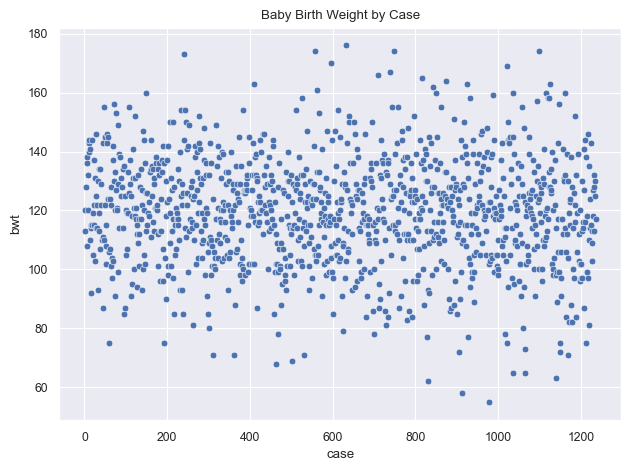

In [284]:
plt.Figure(figsize= (3, 3))
sns.set_theme('paper')

sns.scatterplot(data= df, y= 'bwt', x= 'case')
plt.title('Baby Birth Weight by Case')

plt.tight_layout()
plt.show()

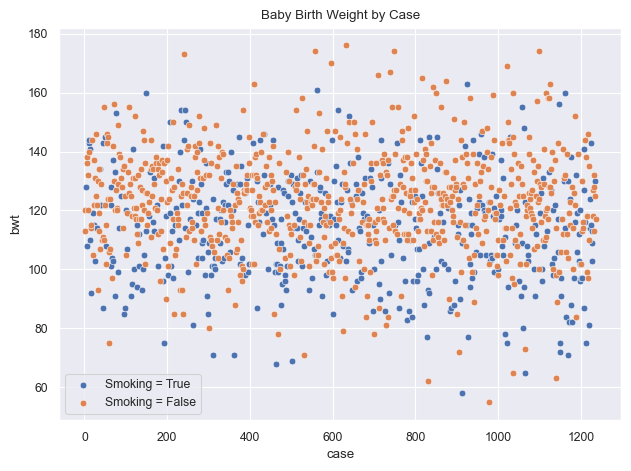

In [285]:
plt.Figure(figsize= (3, 3))
sns.set_theme('paper')

sns.scatterplot(y= df[df['smoke'] == 1]['bwt'], x= df[df['smoke'] == 1]['case'], label= 'Smoking = True')
sns.scatterplot(y= df[df['smoke'] == 0]['bwt'], x= df[df['smoke'] == 0]['case'], label= 'Smoking = False')
plt.title('Baby Birth Weight by Case')

plt.tight_layout()
plt.show()

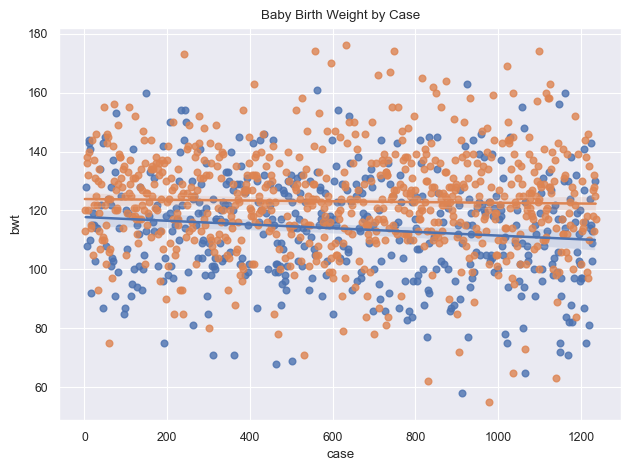

In [286]:
plt.Figure(figsize= (3, 3))
sns.set_theme('paper')

sns.regplot(y= df[df['smoke'] == 1]['bwt'], x= df[df['smoke'] == 1]['case'], label= 'Smoking = True')
sns.regplot(y= df[df['smoke'] == 0]['bwt'], x= df[df['smoke'] == 0]['case'], label= 'Smoking = False')
plt.title('Baby Birth Weight by Case')

plt.tight_layout()
plt.show()

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> bwt = -80.4109 -8.4007 (smoke: 1 = smoked, 0 = did not smoke) + 0.4440 (gestation) -3.3272 (parity) -0.0090 (age) + 1.1540 (height) + 0.0502 (weight) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: The population smoke $\beta_1$ = 0

Ha: The population smoke $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE[$\beta_1$]

t-stat = (-8.4007 - 0) / 0.954

t-stat = -8.807

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.0001

$\alpha$ = 0.05

=> p-value < $\alpha$

=> 0.0001 < 0.05

=> We reject the null hypothesis; the population smoke $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [-8.4007 - (1.96 * 0.954), -8.4007 + (1.96 * 0.954)]

Confidence Interval = [-10.272, -6.529]

=> Confidence interval does not contain zero.

=> Therefore results confirm hypothesis test and population smoke $\beta_1$ is not zero.

### **Description, Reasoning, and Summary:**
- The results of the model confirm our innitial assumption; while holding all else constant, smoking during pragnancy does lead to a decrease in baby birth weight.
- Under the assumption that all cofounders are controlled for and the expected error term is zero, the relationship can be interpreted as causal.
- The relationship states that the average treatment effect (ATE), or the average difference between the treatment and control groups, is -8.4007.
- The sample data also may confirm this relationship to be interpreted as causal, given the fact that the ATE is statistically significant.
- The probability of observing a test statistic as extreme as the one observed (t-stat = -8.807), given the null hypothesis is true, is low (p-value = 0.0001).
- Therefore, we have sufficient evidence to reject the null hypothesis for the alternative.
- The population smoke $\beta_1$ coefficient is not equal to zero, and there does exist a significant relationship that can be inferred as causal.
- However, statistical significance does not mean the relationship between smoking and baby body weight is causal since smoking is not random and therefore other unobserved cofounders may be affecting the relationship.

---

# **(3) COVID Lockdowns: Did COVID lockdowns cause a larger decrease in student scores at poorer schools?**

### **Dataset Used:**

https://www.kaggle.com/datasets/dylanbollard/covid19-effect-on-grades-constructed-dataset

### **Dataset Description:**
This dataset was generated in order to fullfill a requirement for a graduate class in applied econometrics. I originally wanted to collect data on the effect of COVID-19 on student performance from a school district, but was unable to given that our local district was already conducting their own research.

The set contains a panel dataset, meant to emulate 6 semesters/trimesters with the first three taking place before the COVID-19 lockdowns, and the final three coming after the lockdowns. It also contains a cross-sectional dataset that is meant to be a single semester/trimester after the COVID-19 lockdowns. Variables were included and manipulated to model real world trends, or local demographics in Portland Oregon. There is a full list of variables at the end of this markdown.

It should be noted that student performance has greatly been diminished as a result of online education.

### **VARIABLES used in the program (NAME DATATYPE PURPOSE):**

### **PERSONAL INFORMATION:**

- studentID into Number assigned to student. 
- school dummy 0/1, bool 1=school B (poor), 0= school A (wealthy)
- gradelevel int Determine grade level of child.
- gender dummy 0/1, bool 1=male, 0=female 
- covidpos dummy 0/1 1=child had Covid, 0=null 
- freelunch dummy 0/1 1=takes free and reduced lunch, 0=null
- timeperiod categorical {0,1,2}=in-person learning, {3,4,5}=online learning 
- numcomputers into Defines number of computers in child's home. 
- familysize int Defines size of family, parents and siblings.
- householdincome float Household income for child. 
- fathereduc categorical System of values for highest level of father education, no HS diploma = 0, High School diploma 1, Highest level of education is High School. Bachelor degre = 2. Master's Degree = 3. Doctoral Degree = 4. Then, if fathereduc = 0, father did not finish High School.
- mothereduc categorical System of values for highest level of mother education, no HS diploma = 0, High School diploma = 1 Highest level of education is High School. Bachelor degre = 2. Master's Degree = 3. Doctoral Degree = 4. Then, if mothereduc = 0, mother did not finish High School. 

### **SCHOOL PERFORMANCE INFORMATION:**
- readingscore float Score for "reading" test in school.
- writingscore float Score for "writing" test in school.
- mathscore float Score for "math" test in school.

### **STATE PERFORMANCE INFORMATION:**
- readingscoreSL float Score for "reading" test at state level.
- writingscoreSL float Score for "writing" test at state level.
- mathscoreSL float Score for "math" test at state level.

### **Innitial Assumption:**
- Did COVID lockdowns cause a larger decrease in student scores at poorer schools?

### **Linear Regression Difference in Difference Design for Causal Effect:**

> $y$ = $\beta_0$ + $\beta_1$ $D_i$ + $\beta_2$ $P_t$ + $\beta_3$ ($D_i$ * $P_t$) + $\epsilon_{it}$

$y$ = The outcome variable. The dependent variable.

$\beta_0$ = The average change in the outcome of the control group before treatment.

$\beta_1$ = The average change in the outcome of the treated group before treatment.

$D_i$ = The treatment variable. The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\beta_2$ = The average change in the outcome of the control group after treatment.

$P_t$ = The post variable. When $P_t$ = 1 = after treated, when $P_t$ = 0 = before treated.

$\beta_3$ = The Average Treatment Effect of the Treated (ATT). The difference between the treatment and control groups after treatment. Measures the estimated causal effect.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Student average across all school tests and state level tests.
- This variable must be calculated from the columns:
    - readingscore float Score for "reading" test in school.
    - writingscore float Score for "writing" test in school.
    - mathscore float Score for "math" test in school.
    - readingscoreSL float Score for "reading" test at state level.
    - writingscoreSL float Score for "writing" test at state level.
    - mathscoreSL float Score for "math" test at state level.

### **Treatment Variable:**
- school dummy variable, where 1 = school B (poor), and 0 = school A (wealthy).
- This treatment variable is not randomly assigned to the sample since it is a choice to go to school B and A.
- Treatment is not assigned at random and therefore cofounders must be accounted for.

### **Post Variable:**
- A before and after COVID-19 lockdown variable.
- This must be calculated using the timeperiod categorical variable, where {0,1,2} = in-person learning before lockdowns, and {3,4,5} = online learning after lockdowns occur.

### **Possible Cofounders:**
- gradelevel int Determine grade level of child.
- gender dummy 0/1, bool 1=male, 0=female 
- covidpos dummy 0/1 1=child had Covid, 0=null 
- freelunch dummy 0/1 1=takes free and reduced lunch, 0=null
- numcomputers into Defines number of computers in child's home. 
- familysize int Defines size of family, parents and siblings.
- householdincome float Household income for child. 
- fathereduc categorical System of values for highest level of father education, no HS diploma = 0, High School diploma 1, Highest level of education is High School. Bachelor degre = 2. Master's Degree = 3. Doctoral Degree = 4. Then, if fathereduc = 0, father did not finish High School.
- mothereduc categorical System of values for highest level of mother education, no HS diploma = 0, High School diploma = 1 Highest level of education is High School. Bachelor degre = 2. Master's Degree = 3. Doctoral Degree = 4. Then, if mothereduc = 0, mother did not finish High School. 

### **Linear Regression Equation for Problem:**
> Std Average across school and state level tests = $\beta_0$ + $\beta_1$ (school, 1 = Poor, 0 = wealthy) + $\beta_2$ (lockdown, 1 = After, 0 = Before) + $\beta_3$ (school * lockdown) + $\beta_4$ (gradelevel) + $\beta_5$ (gender) + $\beta_6$ (positive COVID) + $\beta_7$ (free lunch) + $\beta_8$ (number of computers) + $\beta_9$ (family size) + $\beta_{10}$ (household income) + $\beta_{11}$ (father education) + $\beta_{12}$ (mother education) + $\epsilon_{it}$

## **Importing and Cleaning Dataframe:**

In [287]:
df = pd.read_excel("C:\BROCK U COURSE DOCS\DataSets\COVID-19-Constructed-Dataset-(PANEL).xlsx")
df.head()

,studentID,school,gradelevel,gender,covidpos,householdincome,freelunch,numcomputers,familysize,fathereduc,mothereduc,readingscore,writingscore,mathscore,readingscoreSL,writingscoreSL,mathscoreSL,timeperiod
0,1,0,6,1,1,59065.136719,0,5,3,1,0,73.393600,68.847290,86.905823,84.650970,83.348419,71.108353,2
1,1,0,6,1,1,59065.136719,0,5,3,1,0,62.566071,73.258034,56.995117,77.571396,74.594040,57.717148,4
2,1,0,6,1,1,59065.136719,0,5,3,1,0,79.965630,67.070084,56.612415,87.659691,80.292519,85.021355,1
3,1,0,6,1,1,59065.136719,0,5,3,1,0,68.552406,55.633102,73.727753,69.650352,48.293591,86.596375,3
4,1,0,6,1,1,59065.136719,0,5,3,1,0,82.541451,87.166336,65.315819,68.989784,85.802025,65.637871,0


In [288]:
df.duplicated().sum()

np.int64(0)

In [289]:
df.isna().sum()

studentID          0
school             0
gradelevel         0
gender             0
covidpos           0
householdincome    0
freelunch          0
numcomputers       0
familysize         0
fathereduc         0
mothereduc         0
readingscore       0
writingscore       0
mathscore          0
readingscoreSL     0
writingscoreSL     0
mathscoreSL        0
timeperiod         0
dtype: int64

> No NaN value and no duplicated rows. The data is perfectly clean

In [306]:
df['std_avg'] = (df['readingscore'] + df['writingscore'] + df['mathscore'] + df['readingscoreSL'] + df['writingscoreSL'] + df['mathscoreSL']) / 6

> Created the student average column across both school and state levels for the outcome variable.

In [291]:
df['lockdown'] = df['timeperiod'].map({0: 0, 1: 0, 2: 0, 
                                       3: 1, 4: 1, 5: 1})

> Creating lockdown before (0) and after (1) column for post variable.

In [292]:
df['school_lockdown'] = df['school'] * df['lockdown']

> Creating the average treatment effect on the treated variable. Where the school is poor (treatment school = 1) and after the lockdown (lockdown = 1).

## **Difference in Difference Designed Model**

In [293]:
df.columns

Index(['studentID', 'school', 'gradelevel', 'gender', 'covidpos',
       'householdincome', 'freelunch', 'numcomputers', 'familysize',
       'fathereduc', 'mothereduc', 'readingscore', 'writingscore', 'mathscore',
       'readingscoreSL', 'writingscoreSL', 'mathscoreSL', 'timeperiod',
       'std_avg', 'lockdown', 'school_lockdown'],
      dtype='object')

In [294]:
y = df['std_avg']

x = df[['school', 'lockdown', 'school_lockdown', 'gradelevel', 'gender', 
        'covidpos', 'householdincome', 'freelunch', 'numcomputers', 'familysize', 
        'fathereduc', 'mothereduc']]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                std_avg   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     1057.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:53:21   Log-Likelihood:                -26822.
No. Observations:                8400   AIC:                         5.367e+04
Df Residuals:                    8387   BIC:                         5.376e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              74.1258      0.549    134.973      0.000      73.049      75.202
school             -6.6628      0.286    -23.275      0.000      -7.224      -6.102
lockdown           -8.0374      0.182    -44.104      0.000      -8.395      -7.680
school_lockdown     0.2013      0.257      0.782      0.434      -0.303       0.706
gradelevel         -0.0125      0.032     -0.389      0.698      -0.076       0.051
gender              0.3144      0.129      2.438      0.015       0.062       0.567
covidpos           -2.5229      0.149    -16.885      0.000      -2.816      -2.230
householdincome  5.586e-05   3.25e-06     17.198      0.000    4.95e-05    6.22e-05
freelunch           0.3352      0.204      1.641      0.101      -0.065       0.735
numcomputers        0.0530      0.047      1.139      0.255      -0.038       0.144
familysize         -0.4173      0.063     -6.663      0.000      -0.540      -0.295
fathereduc          1.6353      0.078     20.952      0.000       1.482       1.788
mothereduc          0.6922      0.079      8.756      0.000       0.537       0.847
==============================================================================
Omnibus:                      167.078   Durbin-Watson:                   1.838
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.014
Skew:                          -0.288   Prob(JB):                     6.09e-44
Kurtosis:                       3.486   Cond. No.                     8.43e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.43e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

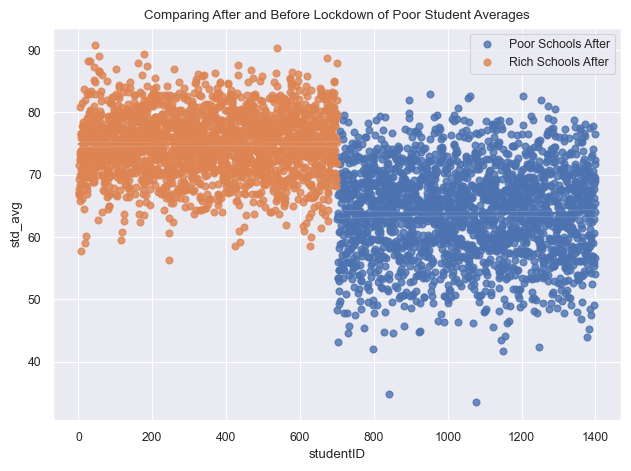

In [304]:
afterLockdown_andPoor = df[(df['lockdown'] == 1) & (df['school'] == 1)]
afterLockdown_andRich = df[(df['lockdown'] == 1) & (df['school'] == 0)]

plt.Figure(figsize= (5, 5))
sns.set_theme('paper')

sns.regplot(data= afterLockdown_andPoor, x= 'studentID', y= 'std_avg', label= 'Poor Schools After')
sns.regplot(data= afterLockdown_andRich, x= 'studentID', y= 'std_avg', label= 'Rich Schools After')
plt.title('Comparing After and Before Lockdown of Poor Student Averages')
plt.legend()

plt.tight_layout()
plt.show()

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Student average across school and state level tests = 74.1258 -6.6628 (school, 1 = Poor, 0 = wealthy) -8.0374 (lockdown, 1 = After, 0 = Before) + 0.2013 (school * lockdown) -0.0125 (gradelevel) + 0.3144 (gender) -2.5229 (positive COVID) + 5.586e-05 (household income) + 0.3352 (free lunch) + 0.0530 (number of computers) -0.4173 (family size) + 1.6353 (father education) + 0.6922 (mother education) + $\epsilon_{it}$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: Population poor school and after lockdown (Average Treatment Effect on the Treated ATT) $\beta_3$ = 0

Ha: Population poor school and after lockdown (Average Treatment Effect on the Treated ATT) $\beta_3$ != 0

t-stat = ($\beta_3$ - 0) / SE[$\beta_3$]

t-stat = (0.2013 - 0) / 0.257

t-stat = 0.782

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.434

$\alpha$ = 0.05

=> p-value > $\alpha$

=> 0.434 > 0.05

=> We fail to reject the null hypothesis; the population poor school and after lockdown (Average Treatment Effect on the Treated ATT) $\beta_3$ = 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_3$ - (t[0.05] * SE), $\beta_3$ + (t[0.05] * SE)]

Confidence Interval = [0.2013 - (1.96 * 0.257), 0.2013 + (1.96 * 0.257)]

Confidence Interval = [-0.303, 0.706]

=> Confidence interval contains zero, and therefore these results confirm the hypothesis test that population poor school and after lockdown $\beta_3$ = 0.

### **Description, Reasoning, and Summary:**
- The results of the difference in difference model do confirm our innitial assumption relationship.
- We assumed that lockdowns will cause a decrease in student overall averages at a combined state and school level after the lockdowns occur.
- The model shows that the average treatment effect of the treated (ATT) is 0.2013.
- This means that after the lockdowns, the average difference in the changes between the poor and rich school student averages after the lockdowns is 0.2013.
- The change in the student averages is calculated as $\beta_2$ + $\beta_3$, which is -7.8361.
- Students who attend poor schools after the COVID-19 lockdowns, their average grades across school and state level reading, writting, and math tests will decrease, on average, by 7.8361 percentage points.
- Poor school student averages decreased by 0.2013 
- However, we cannot say this relationship is causal due to two factors: The treatment is not randomly assigned, and the ATT ($\beta_3$) is statistically insignificant.
- The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true is 0.434.
- This high p value is much greater than the 0.05 threshold, meaning the sample data confirms the truth of the assumption; the hypothesis test has failed to be rejected.
- The Population of poor school AND after lockdown $\beta_3$ coefficient is equal to zero.
- The is not enough information to conclude the statistical significance of $\beta_3$, and so we cannot infer causality between the varaibles of the relationship.

---